In [1]:
import gymnasium as gym 
import panda_gym 
from numpngw import write_apng 

In [14]:
env_id ="PandaReach-v3"



env = gym.make(env_id,render_mode="human")

state,_ = env.reset()

env.render()

In [15]:
env.close()

In [16]:

env = gym.make(env_id,render_mode="human")

state,_ = env.reset()


print(env.observation_space)

Dict('achieved_goal': Box(-10.0, 10.0, (3,), float32), 'desired_goal': Box(-10.0, 10.0, (3,), float32), 'observation': Box(-10.0, 10.0, (6,), float32))


In [17]:
print(env.action_space)

Box(-1.0, 1.0, (3,), float32)


In [18]:
state

{'observation': array([ 3.8439669e-02, -2.1944723e-12,  1.9740014e-01,  0.0000000e+00,
        -0.0000000e+00,  0.0000000e+00], dtype=float32),
 'achieved_goal': array([ 3.8439669e-02, -2.1944723e-12,  1.9740014e-01], dtype=float32),
 'desired_goal': array([-0.09416945,  0.02276687,  0.02894157], dtype=float32)}

In [19]:
env.action_space.sample()
env.close()

In [20]:
images = [] 


episodes = 10 
env = gym.make(env_id,render_mode="rgb_array")
for episode in range(episodes): 
    done = False 
    obs,_ = env.reset() 
    images.append(env.render())
    total_reward =  0 
    while not done : 
        action = env.action_space.sample() 
        obs,reward,terminated,truncated,_ = env.step(action)
        total_reward += reward 
        done = terminated or truncated 
        images.append(env.render())
    print(f"Episode {episode}   with reward {total_reward}")    

Episode 0   with reward -50.0
Episode 1   with reward -50.0
Episode 2   with reward -50.0
Episode 3   with reward -50.0
Episode 4   with reward -7.0
Episode 5   with reward -50.0
Episode 6   with reward -1.0
Episode 7   with reward -50.0
Episode 8   with reward -50.0
Episode 9   with reward 0.0


In [21]:
image_files  = f"./images/random_{env_id}.png"

In [22]:
write_apng(image_files,images,delay=100)

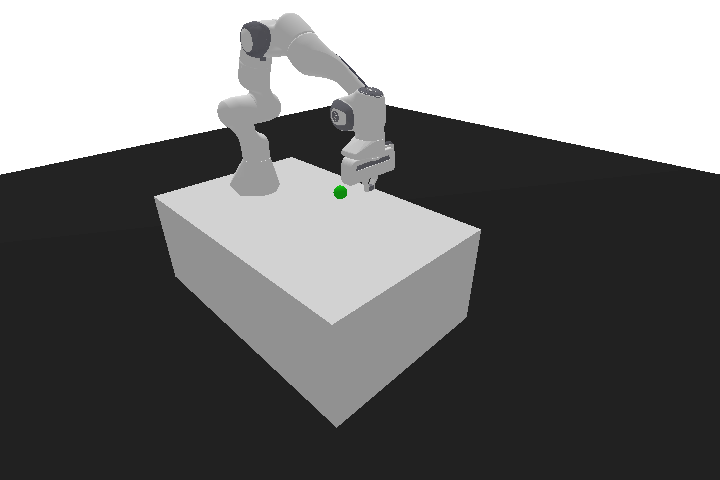

In [23]:
from IPython.display import Image 

Image(image_files)

In [24]:
reward_history_before = []
reward_history_after = []  
episodes = 32


for episode in range(episodes):
    obs, info = env.reset()
    done = False
    total_reward_before = 0
    while not done:
        action = env.action_space.sample() 
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward_before += reward
        if terminated or truncated:
            done = True
    reward_history_before.append(total_reward_before)
    print(f"Episode: {episode + 1}, Total Reward Before: {total_reward_before}")

print(f"Average Reward Before: {sum(reward_history_before) / episodes}")

Episode: 1, Total Reward Before: -50.0
Episode: 2, Total Reward Before: -50.0
Episode: 3, Total Reward Before: -50.0
Episode: 4, Total Reward Before: -50.0
Episode: 5, Total Reward Before: -50.0
Episode: 6, Total Reward Before: -50.0
Episode: 7, Total Reward Before: -50.0
Episode: 8, Total Reward Before: -1.0
Episode: 9, Total Reward Before: -50.0
Episode: 10, Total Reward Before: -50.0
Episode: 11, Total Reward Before: -50.0
Episode: 12, Total Reward Before: -15.0
Episode: 13, Total Reward Before: -50.0
Episode: 14, Total Reward Before: -50.0
Episode: 15, Total Reward Before: -50.0
Episode: 16, Total Reward Before: -4.0
Episode: 17, Total Reward Before: -50.0
Episode: 18, Total Reward Before: -50.0
Episode: 19, Total Reward Before: -50.0
Episode: 20, Total Reward Before: -50.0
Episode: 21, Total Reward Before: -50.0
Episode: 22, Total Reward Before: -50.0
Episode: 23, Total Reward Before: -50.0
Episode: 24, Total Reward Before: -50.0
Episode: 25, Total Reward Before: -50.0
Episode: 26

In [25]:

for episode in range(episodes):
    obs, info = env.reset()
    done = False
    total_reward_after = 0
    while not done:
        action,_ = model.predict(obs,deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward_after += reward
        if terminated or truncated:
            done = True
    reward_history_after.append(total_reward_after)
    print(f"Episode: {episode + 1}, Total Reward after: {total_reward_after}")

print(f"Average Reward after: {sum(reward_history_after) / episodes}")

NameError: name 'model' is not defined